# Day 17 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('new_insurance_data.csv')

In [6]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


First we'll analysse the data

### Analysing the data and cleaning the data

In [7]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [8]:
df.tail()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,170380500.5,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,201515184.8,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,223644981.3,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,252892382.6,3.0,4.006359e+09,southeast,62592.87309
1337,54.0,female,47.410,0.0,yes,63982.80926,31.0,1100328.0,261631699.3,3.0,4.117197e+09,southeast,63770.42801


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [10]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [11]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [12]:
sum_na = df.isnull().sum().sum()
sum_na

52

#### If less than 10% values , remove them , else replace

In [13]:
df.shape

(1338, 13)

In [14]:
rows = df.shape[0]
col = df.shape[1]

In [15]:
print((52/rows)*100)

3.8863976083707024


its 3% overall, but we havr to check in each columns 

In [16]:
#here i can drop na
df.dropna(inplace=True)

In [17]:
df.isna().sum().sum()

0

In [18]:
df.duplicated().sum()

0

In [19]:
#outliers 
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

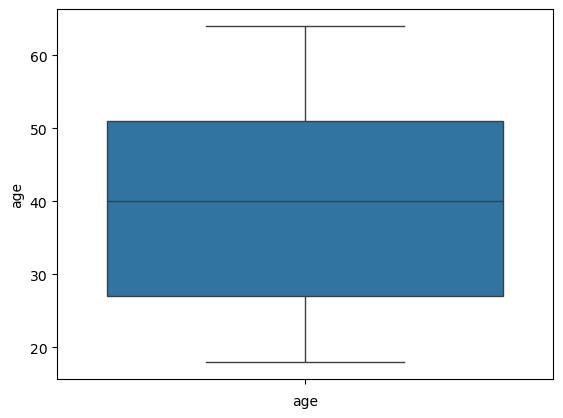

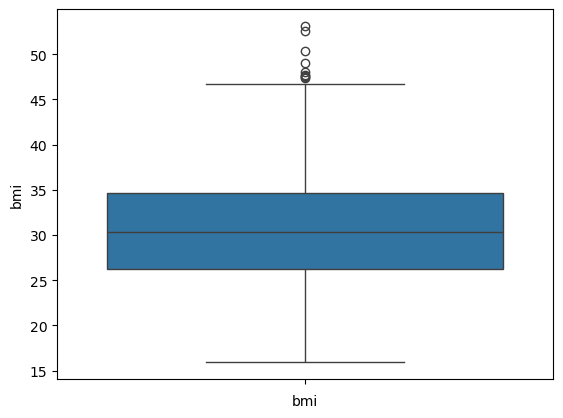

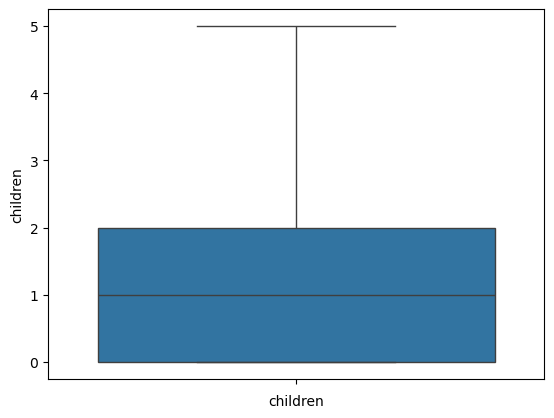

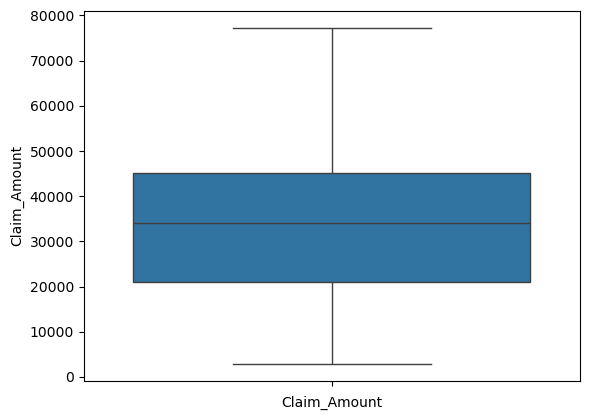

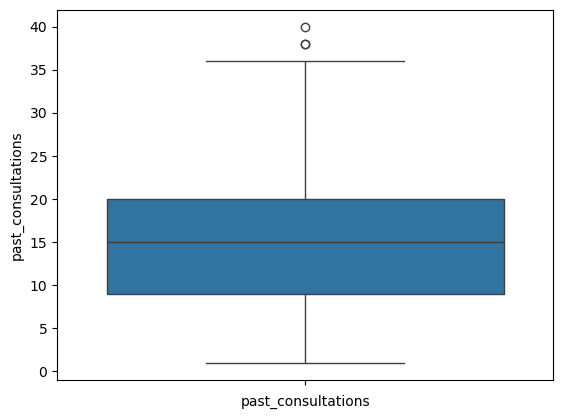

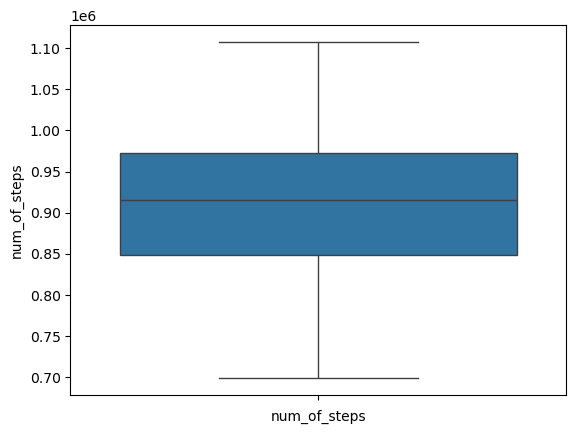

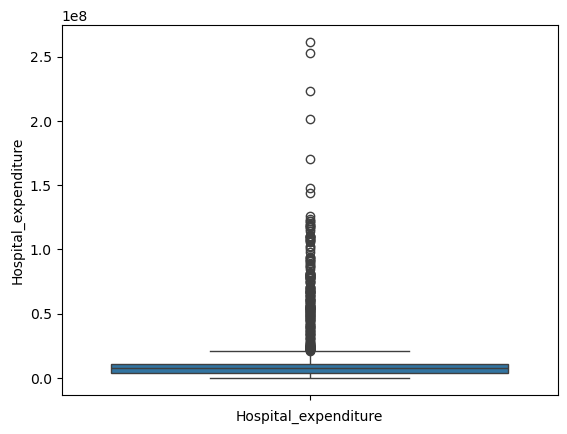

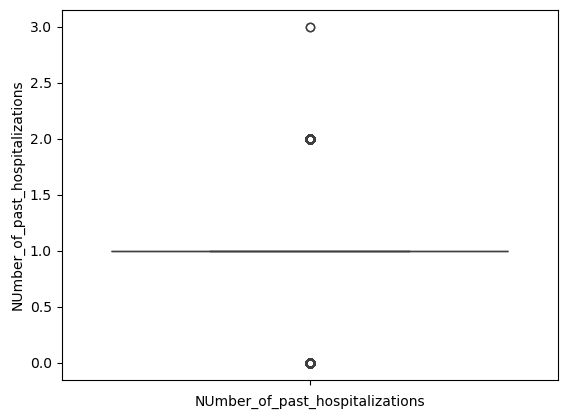

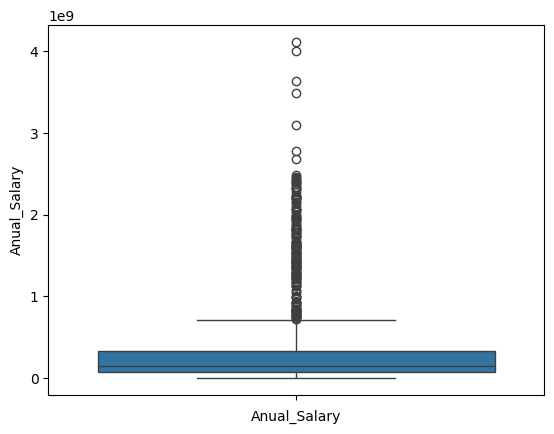

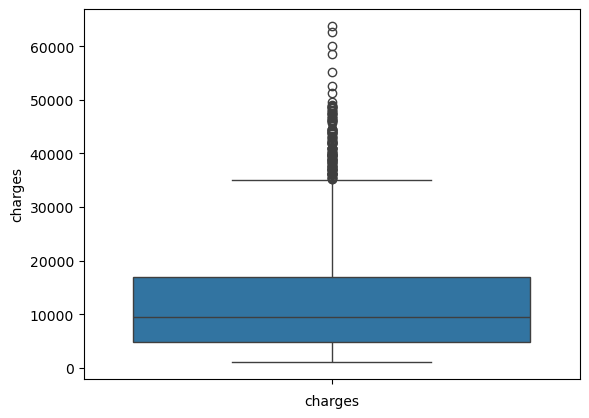

In [20]:
#only for numerical values
for i in df.columns:
    if (df[i].dtypes=='int') | (df[i].dtypes=='float'):
        plt.figure() # This creates a new figure for each plot
        sns.boxplot(df[i])
        plt.xlabel(i)


In [21]:
#we'll not remove outliers which can be natural extremes - moreover a medical data 
#all outliers are natural (seems like that till now !)


Independent Variable (column) - CGPA , backs , Projects , internships
  - They are the columns which decides the outcomes - they are columns which will used to predict the dependend 

Dependent Variable (columns) - Package
  - They are what we are predicting, they are dependent to those values 

### Multicollinearity
When there are two or more independent columns or variables are there which are highly correlated with each other.

### Effect of Multicollinearity

age inc --> salary inc
exp inc --> salary inc

age and exp having similar effect on salary ... but which column importance is more 

1. This will not have any issue on the prediction column
2. But , this will effect the feature importance , because when we have multiple columns the same way. model gets confused

### VIF (variance inflation factor)
Check for multicolinearity.

Highers the VIF --> more the column is correlated with other columns.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols=[]
for i in df.columns:
 if df[i].dtypes!='object' and i!='charges':
  cols.append(i)
print(cols)

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'num_of_steps', 'Hospital_expenditure', 'NUmber_of_past_hospitalizations', 'Anual_Salary']


In [23]:
data = df[cols]
data

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
0,18.0,23.210,0.0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07
1,18.0,30.140,0.0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07
2,18.0,33.330,0.0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07
3,18.0,33.660,0.0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07
4,18.0,34.100,0.0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07
...,...,...,...,...,...,...,...,...,...
1333,33.0,35.530,0.0,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09
1334,31.0,38.095,1.0,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09
1335,52.0,34.485,3.0,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09
1336,45.0,30.360,0.0,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09


In [24]:
vif = pd.DataFrame()
vif['Columns']=data.columns
vif['VIF']=0
vif

,Columns,VIF
0,age,0
1,bmi,0
2,children,0
3,Claim_Amount,0
4,past_consultations,0
5,num_of_steps,0
6,Hospital_expenditure,0
7,NUmber_of_past_hospitalizations,0
8,Anual_Salary,0


In [25]:
data.values #it creates a matrix from dataframe 

array([[1.80000000e+01, 2.32100000e+01, 0.00000000e+00, ...,
        4.72092099e+06, 0.00000000e+00, 5.57849700e+07],
       [1.80000000e+01, 3.01400000e+01, 0.00000000e+00, ...,
        4.32983168e+06, 0.00000000e+00, 1.37008852e+07],
       [1.80000000e+01, 3.33300000e+01, 0.00000000e+00, ...,
        6.88486077e+06, 0.00000000e+00, 7.35231073e+07],
       ...,
       [5.20000000e+01, 3.44850000e+01, 3.00000000e+00, ...,
        2.23644981e+08, 2.00000000e+00, 3.64080668e+09],
       [4.50000000e+01, 3.03600000e+01, 0.00000000e+00, ...,
        2.52892383e+08, 3.00000000e+00, 4.00635850e+09],
       [5.40000000e+01, 4.74100000e+01, 0.00000000e+00, ...,
        2.61631699e+08, 3.00000000e+00, 4.11719664e+09]])

In [26]:
#actual vif
vif_values=[]
for i in range(len(cols)): #i--> 0,1,2,3...n
    v=variance_inflation_factor(data.values,i)
#it expects matrix hence data.values- not dataframe
#second it expects which column we have to calculate vif
    vif_values.append(v)
vif['VIF']=vif_values

In [27]:
vif

,Columns,VIF
0,age,11.889264
1,bmi,26.415705
2,children,1.957933
3,Claim_Amount,6.945681
4,past_consultations,8.586173
5,num_of_steps,60.555661
6,Hospital_expenditure,27.435063
7,NUmber_of_past_hospitalizations,17.696136
8,Anual_Salary,37.965843


In [28]:
#vif is high means its corelated with many columns - num of steps having more co-relation

# Day 18

In [37]:
d= df.copy()
d

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [38]:
d.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1287.000000,1287.000000,1287.000000,1287.000000,1287.000000,1.287000e+03,1.287000e+03,1287.000000,1.287000e+03,1287.000000
mean,39.419580,30.655746,1.094794,33498.578933,15.247086,9.113778e+05,1.579929e+07,1.068376,3.727972e+08,13366.072420
std,14.051987,6.086323,1.202782,15611.720348,7.457366,9.083364e+04,2.653821e+07,0.529079,5.655770e+08,12025.821700
min,18.000000,15.960000,0.000000,2912.590584,1.000000,6.991570e+05,2.945253e+04,0.000000,3.150786e+06,1121.873900
25%,27.000000,26.220000,0.000000,20905.974820,9.000000,8.489270e+05,4.114357e+06,1.000000,7.964523e+07,4842.251225
50%,40.000000,30.360000,1.000000,33968.774160,15.000000,9.152840e+05,7.567064e+06,1.000000,1.451129e+08,9549.565100
75%,51.000000,34.600000,2.000000,45152.414195,20.000000,9.726140e+05,1.093014e+07,1.000000,3.337660e+08,16964.132700
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [48]:
df = df.drop(['num_of_steps'],axis=1)
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [55]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)

data=df[cols]


vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0
print(vif)

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values


print(vif)

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'Hospital_expenditure', 'NUmber_of_past_hospitalizations', 'Anual_Salary']
                           Columns  VIF
0                              age    0
1                              bmi    0
2                         children    0
3                     Claim_Amount    0
4               past_consultations    0
5             Hospital_expenditure    0
6  NUmber_of_past_hospitalizations    0
7                     Anual_Salary    0
                           Columns        VIF
0                              age  10.094843
1                              bmi  12.336735
2                         children   1.944907
3                     Claim_Amount   6.389117
4               past_consultations   7.746533
5             Hospital_expenditure  27.374979
6  NUmber_of_past_hospitalizations  15.364271
7                     Anual_Salary  37.876016


In [56]:
#corelation is changed again - now annual salary has more vif so we'll drop that

In [57]:
df = df.drop(['Anual_Salary'],axis=1)

In [59]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'region', 'charges'],
      dtype='object')

In [60]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)

data=df[cols]


vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0
print(vif)

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values


print(vif)

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'Hospital_expenditure', 'NUmber_of_past_hospitalizations']
                           Columns  VIF
0                              age    0
1                              bmi    0
2                         children    0
3                     Claim_Amount    0
4               past_consultations    0
5             Hospital_expenditure    0
6  NUmber_of_past_hospitalizations    0
                           Columns        VIF
0                              age   9.873895
1                              bmi  11.182301
2                         children   1.914599
3                     Claim_Amount   6.364278
4               past_consultations   7.324500
5             Hospital_expenditure   2.579248
6  NUmber_of_past_hospitalizations  11.478975


In [61]:
#anything above 10 is bad VIF

In [63]:
df =df.drop(['NUmber_of_past_hospitalizations'],axis=1)

In [64]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)

data=df[cols]


vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0
print(vif)

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values


print(vif)

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'Hospital_expenditure']
                Columns  VIF
0                   age    0
1                   bmi    0
2              children    0
3          Claim_Amount    0
4    past_consultations    0
5  Hospital_expenditure    0
                Columns        VIF
0                   age   8.309772
1                   bmi  11.154995
2              children   1.818798
3          Claim_Amount   6.088357
4    past_consultations   6.919598
5  Hospital_expenditure   1.909801


In [65]:
#bmi is above 10 still
df=df.drop(['bmi'],axis=1)

In [66]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)

data=df[cols]


vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0
print(vif)

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values


print(vif)

['age', 'children', 'Claim_Amount', 'past_consultations', 'Hospital_expenditure']
                Columns  VIF
0                   age    0
1              children    0
2          Claim_Amount    0
3    past_consultations    0
4  Hospital_expenditure    0
                Columns       VIF
0                   age  5.753673
1              children  1.786858
2          Claim_Amount  5.313145
3    past_consultations  6.272636
4  Hospital_expenditure  1.891579


In [67]:
#now its better (there are very less multi colinear columns)

In [68]:
print(df)

       age     sex  children smoker  Claim_Amount  past_consultations  \
0     18.0    male       0.0     no   29087.54313                17.0   
1     18.0    male       0.0     no   39053.67437                 7.0   
2     18.0    male       0.0     no   39023.62759                19.0   
3     18.0    male       0.0     no   28185.39332                11.0   
4     18.0    male       0.0     no   14697.85941                16.0   
...    ...     ...       ...    ...           ...                 ...   
1333  33.0  female       0.0    yes   63142.25346                32.0   
1334  31.0  female       1.0    yes   43419.95227                31.0   
1335  52.0    male       3.0    yes   52458.92353                25.0   
1336  45.0    male       0.0    yes   69927.51664                34.0   
1337  54.0  female       0.0    yes   63982.80926                31.0   

      Hospital_expenditure     region      charges  
0             4.720921e+06  southeast   1121.87390  
1             4.3

In [69]:
#some columns having objects - we have to convert them to numerical values

## Label Encoding
Is a way to convert catogerical columns to numerical columns .

Because most of the ML models works with numbers

In [78]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder() #use to convert catogery into numbers

for i in df.columns:
    if df[i].dtypes=='object':
        df[i]=le.fit_transform(df[i])

In [79]:
df

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region,charges
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2,1121.87390
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2,1131.50660
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2,1135.94070
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2,1136.39940
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2,1137.01100
...,...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1,55135.40209
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0,58571.07448
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1,60021.39897
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2,62592.87309


## Splitting data into independent (input) nd dependent (output)

In [80]:
print(df.columns)

Index(['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region', 'charges'],
      dtype='object')


In [101]:
x=df.loc[:,['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region']]
y=df['charges']

In [102]:
#x is indeppendent
x

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2
...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2


In [103]:
y
#dependent

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1333    55135.40209
1334    58571.07448
1335    60021.39897
1336    62592.87309
1337    63770.42801
Name: charges, Length: 1287, dtype: float64

## Train and Test Split


In [104]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0) #y_test is actual output
#x_train 8-% always give random things so we need to fix- hence random_state

In [105]:
x_train

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
510,44.0,1,1.0,0,16460.954610,22.0,8.084459e+06,2
479,33.0,1,5.0,0,41495.241570,10.0,2.395061e+06,2
316,29.0,0,2.0,0,5556.193100,12.0,1.000335e+07,3
803,52.0,0,3.0,0,41327.384140,8.0,2.155938e+06,3
528,18.0,0,0.0,0,8760.653674,10.0,9.268380e+06,0
...,...,...,...,...,...,...,...,...
802,52.0,0,2.0,0,12992.139950,24.0,4.075903e+06,0
875,60.0,1,0.0,0,41844.564980,8.0,1.191697e+07,1
1261,37.0,1,4.0,1,52206.093400,30.0,6.842734e+07,3
595,46.0,1,1.0,0,37775.304960,8.0,5.910532e+06,0


In [106]:
x_test

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
692,52.0,1,0.0,0,8130.290032,15.0,4.265125e+06,0
355,31.0,0,2.0,0,19683.131830,19.0,5.257252e+06,3
1050,31.0,1,0.0,1,24382.580560,21.0,1.028991e+07,2
512,44.0,1,1.0,0,41827.764410,21.0,3.210070e+06,2
845,55.0,1,3.0,0,52155.958830,11.0,7.683186e+06,2
...,...,...,...,...,...,...,...,...
793,33.0,1,1.0,0,36343.864730,11.0,8.089966e+06,2
1098,33.0,1,0.0,0,42750.268640,14.0,1.076586e+07,1
54,18.0,1,1.0,0,28521.842900,12.0,4.960146e+06,2
965,64.0,1,0.0,0,15996.028250,18.0,8.909351e+06,0


In [107]:
y_train

510      7147.472800
479      6653.788600
316      4529.477000
803     11411.685000
528      7323.734819
            ...     
802     11396.900200
875     12523.604800
1261    40182.246000
595      8334.457550
721     10141.136200
Name: charges, Length: 1029, dtype: float64

In [108]:
y_test #actual charge

692      9722.76950
355      4931.64700
1050    19350.36890
512      7152.67140
845     11987.16820
           ...     
793     11326.71487
1098    21984.47061
54       1711.02680
965     14394.55790
971     14455.64405
Name: charges, Length: 258, dtype: float64

## Model Building

In [109]:
from sklearn.linear_model import LinearRegression

In [110]:
model=LinearRegression()

## Train the model

In [111]:
model.fit(x_train,y_train)

LinearRegression()

## Predict the output(charges)--> charges

In [112]:
y_pred=model.predict(x_test)

In [113]:
y_pred

array([ 8945.54344432,  7153.64650188, 19889.77762261, 10071.69553856,
       12705.99674236,  5952.61965387, 18842.5432617 ,  8468.6533737 ,
        3525.54429906,  5630.96058515,  5903.20204204,  7612.80444363,
       42160.56561594, 32284.82242258,  8918.03118061, 51350.05345423,
        2586.36924119, 11359.97978443,  4365.74487791, 13476.49327488,
       12160.47683501,  3725.93439702, 13223.25849431, 11878.70637356,
        2709.13867808,  3766.71087215,  4976.7813816 ,  7549.12641853,
       23174.27329164,  5156.93276088,  4295.16192632, 17221.40122525,
       21085.23007286, 13869.91202861, 10183.43758099,  9077.53240699,
        9773.20058982,  8205.44928516, 11992.66142043, 12582.83606198,
        7590.52485384, 11281.90807919,  2241.81400013, 44299.40902141,
       11973.62267443, 39101.09232075, 36774.14416451,  6854.51681199,
        9990.36900893, 26279.4149761 , 41497.6535347 , 22752.44075085,
        3597.73553237,  3060.21091032,  6427.02110232, 33200.3292197 ,
      

## Comparing the actual

In [114]:
compare=pd.DataFrame()
compare['Actual Charges']=y_test
compare['Predicted Charges']=y_pred
print(compare)

      Actual Charges  Predicted Charges
692       9722.76950        8945.543444
355       4931.64700        7153.646502
1050     19350.36890       19889.777623
512       7152.67140       10071.695539
845      11987.16820       12705.996742
...              ...                ...
793      11326.71487        7226.855049
1098     21984.47061        8430.275628
54        1711.02680        3637.935153
965      14394.55790       13022.556671
971      14455.64405       20995.303635

[258 rows x 2 columns]


## Acuraccy of the model --> R2 Score

In [115]:
from sklearn.metrics import r2_score
r=r2_score(y_test,y_pred)
r

0.8812989568246431

In [116]:
# its normal, can be concidered , better

## we removed the vif , but what if there was not removed vif


In [117]:
le=LabelEncoder()

for i in d.columns:
  if d[i].dtypes=="object":
    d[i]=le.fit_transform(d[i])

In [118]:
x=d.loc[:,['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region']]

y=d['charges']

In [119]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [120]:
model3=LinearRegression()

In [121]:
model3.fit(x_train,y_train)

LinearRegression()

In [122]:
y_pred=model3.predict(x_test)

In [123]:
r=r2_score(y_test,y_pred)
print("R_score without removing the VIF=",r)

R_score without removing the VIF= 0.9937516415541179


In [124]:
#its better, multicolinearity doesnt matter that much- usually removing gives worst - can be said exception
#when you are predicting multicolinearity doesnt matter that much

## Feature Importance-> withut removing multicollinearlity

In [126]:
print(x_train.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region'],
      dtype='object')


In [127]:
print(model3.coef_)

[-1.40046576e+01  9.42781888e+01 -3.16689067e+00 -1.14039841e+02
  8.39392547e+02  1.85167498e-03  4.25291430e+00  4.99621227e-02
 -1.40665882e-04 -6.72814166e+02  2.07745131e-05  1.20706433e+01]


In [128]:
coef=pd.DataFrame({
    'Features' : x_train.columns,
    'Importance': model3.coef_
})
print(coef)

                           Features  Importance
0                               age  -14.004658
1                               sex   94.278189
2                               bmi   -3.166891
3                          children -114.039841
4                            smoker  839.392547
5                      Claim_Amount    0.001852
6                past_consultations    4.252914
7                      num_of_steps    0.049962
8              Hospital_expenditure   -0.000141
9   NUmber_of_past_hospitalizations -672.814166
10                     Anual_Salary    0.000021
11                           region   12.070643


In [129]:
#it is wrong due to high vif - 

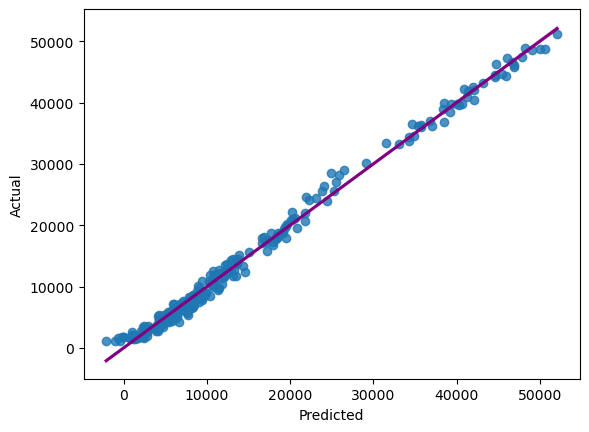

In [132]:
sns.regplot(x=y_pred,y=y_test,line_kws={'color':'purple'}) #redplot=regression plot
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()